New names:
• `` -> `...1`
Rows: 1711601 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Class
dbl  (5): ...1, X, Y, Allsubtypes, neighborhood10
lgl (17): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "...1"           "X"              "Y"              "Class"         
 [5] "Allsubtypes"    "1"              "2"              "3"             
 [9] "4"              "5"              "6"              "7"             
[13] "8"              "9"              "10"             "11"            
[17] "12"             "13"             "14"             "15"            
[21] "16"             "17"             "neighborhood10"

cutree(p$tree_row, k = 5)
 1  2  3  4  5 
26 46 24  3  7 

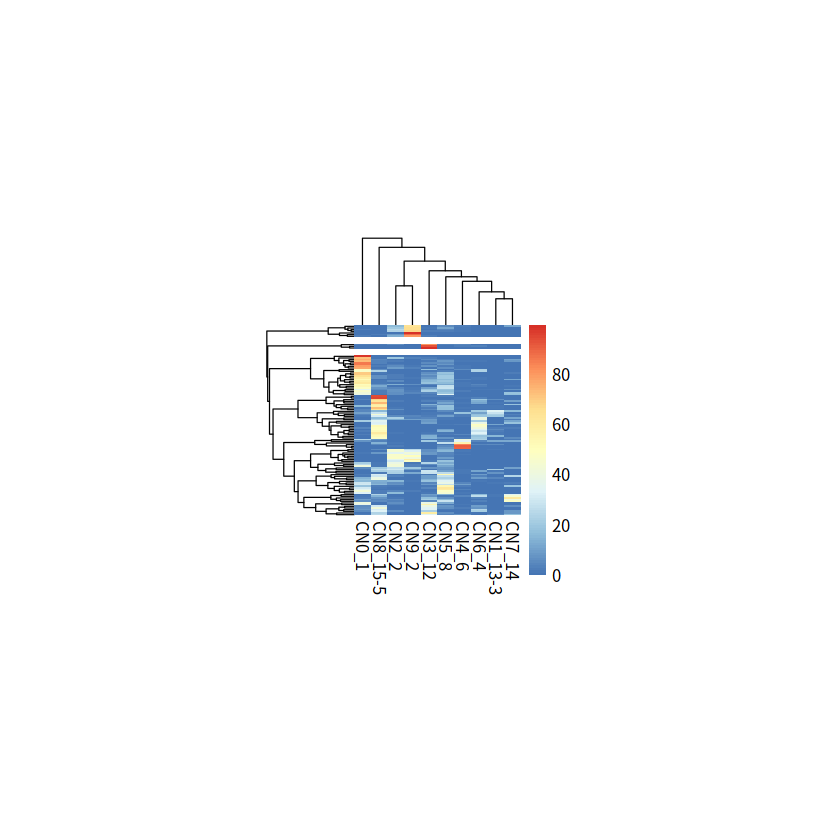

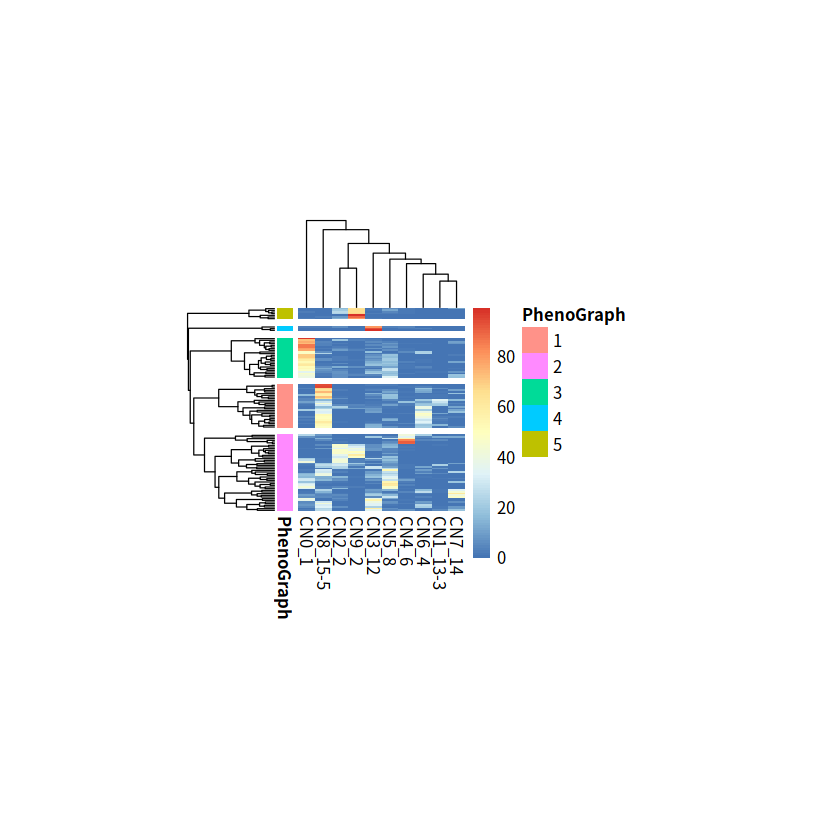

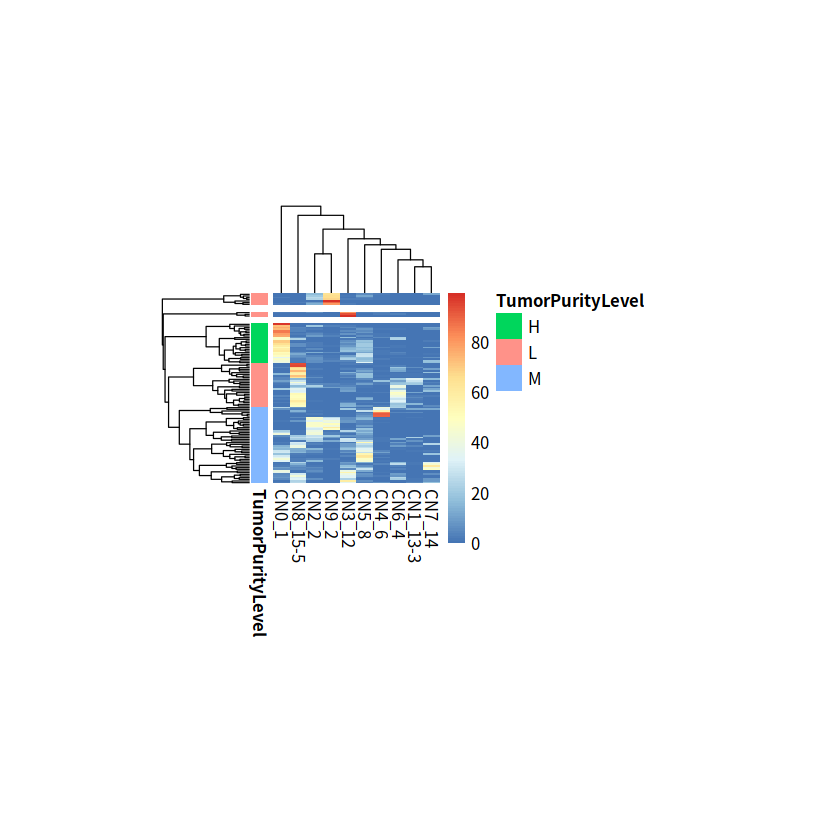

In [9]:

##### R 3.6.3

library(tidyverse) #v1.3.0
library(tidyr)  #v1.1.4
library(Rphenograph)  #v0.99.1
library(ggpubr)   #v0.4.0
library(ggthemes) #v4.2.0
library(Rtsne)  #v0.15
library(flowCore)   #v1.52.1
library(Rcpp)  #v1.0.5
library(igraph) #v1.2.6
library(survival)   #v3.2.7
library(survminer)  #v0.4.8
library(pheatmap)  #v1.0.12
library(ggsci)  #v2.9



#load output data from Python
gc_csd_CN <- read_csv(file = '/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=10.csv')
colnames(gc_csd_CN)
# CN annotation -----------------------------------------------------------

gc_csd_CN_anno <- gc_csd_CN %>% mutate(All_CN=paste0('CN',neighborhood10))

gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN0'] <- 'CN0_1' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN1'] <- 'CN1_13-3' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN2'] <- 'CN2_2' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN3'] <- 'CN3_12' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN4'] <- 'CN4_6' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN5'] <- 'CN5_8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN6'] <- 'CN6_4' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN7'] <- 'CN7_14' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN8'] <- 'CN8_15-5' 
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN9'] <- 'CN9_2'



# ct-based-cn in each region/class -----------------------------------------------------------

cells_CN <- gc_csd_CN_anno %>% dplyr::select(Class, All_CN)


dat <- as.data.frame(with(cells_CN, table(Class, All_CN)))
cells_CN_Freq <- spread(dat, All_CN, Freq)

dat_CN_freq <- cells_CN_Freq[,-1]
row.names(dat_CN_freq) <- cells_CN_Freq$Class


dat_CN_percent <- dat_CN_freq / rowSums(dat_CN_freq) * 100
row.names(dat_CN_percent)<- cells_CN_Freq$Class




# clustering in heatmap ---------------------------------------------------------


# pdf(file = "1_pheatmap_allCN.pdf", width =10, height = 15)
p <- pheatmap(dat_CN_percent,
              cellwidth = 10,
              cellheight = 1,
              show_rownames = F,
              cutree_rows = 3)
# dev.off() 

# pdf(file = "2_pheatmap_allCN.pdf", width =10, height = 15)
# bk <- c(seq(-4,-0.1,by=0.01),seq(0,4,by=0.01))
# p <- pheatmap(dat_CN_percent,
#               cellwidth = 10,
#               cellheight = 1,
#               # annotation_row = df_TP,
#               border=FALSE,
#               color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/2),colorRampPalette(color=c("white","red"))(length(bk)/2)),
#               scale = 'row',
#               cluster_rows = T,
#               show_rownames = F,
#               show_colnames = T,
#               legend_breaks=seq(-4,4,2),
#               breaks=bk,
#               cutree_rows = 14)
# print(p)
# dev.off() 




row_cluster <- as.data.frame(cutree(p$tree_row,k=5))
table(row_cluster)
names(row_cluster) <- 'PhenoGraph'
row_cluster$Class <-  row.names(row_cluster)

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

df_merge <- df_merge[order(df_merge$PhenoGraph),]
temp <- df_merge[,c(-1,-2)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[2]
row.names(anno) <- df_merge$Class
anno$PhenoGraph <- as.factor(anno$PhenoGraph)

p1 <- pheatmap(temp,
               cellwidth = 10,
               cellheight = 1,
               show_rownames = F,
               cutree_rows = 5,
               annotation_row = anno)

df_merge$PhenoGraph[df_merge$PhenoGraph==3] <- 'H'  # cluster 3 
df_merge$PhenoGraph[df_merge$PhenoGraph==1] <- 'L'  #cluster 1,2,5
df_merge$PhenoGraph[df_merge$PhenoGraph==4] <- 'L'  #cluster 1,2,5
df_merge$PhenoGraph[df_merge$PhenoGraph==5] <- 'L'  #cluster 1,2,5
df_merge$PhenoGraph[df_merge$PhenoGraph==2] <- 'M'  # cluster 4

df_merge <- df_merge %>% dplyr::rename(TumorPurityLevel=PhenoGraph)

anno <- df_merge[2]
row.names(anno) <- df_merge$Class
temp <- df_merge[,c(-1,-2)]
row.names(temp) <- df_merge$Class 
p1 <- pheatmap(temp,
               cellwidth = 10,
               cellheight = 1,
               show_rownames = F,
               cutree_rows = 3,
               annotation_row = anno)



# combination of TPL with clinical information -----------------------------------------------------

mydata_pheno <- df_merge
row.names(mydata_pheno) <- dat_CN_percent_class$Class
mydata_pheno$Class0 <- rownames(mydata_pheno)
mydata_pheno$Class0 <- as.character(mydata_pheno$Class0)



# TPL, TP, SP and clinical information for each region/class -----------------------------------------------------------------------


# CN_basedon_celltype <- read.csv('mydata_pheno_anno_ctCN.csv',header = T,row.names = 1,stringsAsFactors = F)
# colnames(CN_basedon_celltype)[3:12] <- paste0('ct_based_',colnames(CN_basedon_celltype)[3:12])
# CN_basedon_celltype <- CN_basedon_celltype[2:13]
# CN_basedon_celltype <- dplyr::rename(CN_basedon_celltype, Class=Class0)

# Class_Pheno_Anno <- read.csv('Class_Pheno_Anno.csv',header = T,row.names = 1,stringsAsFactors = F)

# Class_Pheno_Anno_ctCN <- merge(CN_basedon_celltype,Class_Pheno_Anno,by='Class')


# write.csv(Class_Pheno_Anno_ctCN,file = 'Class_Pheno_Anno_ctCN.csv')


In [12]:
write.table(mydata_pheno, file = "mydata_pheno02.csv", sep = ",", row.names = TRUE, quote = FALSE)


In [11]:
mydata_pheno

,Class,TumorPurityLevel,CN0_1,CN1_13-3,CN2_2,CN3_12,CN4_6,CN5_8,CN6_4,CN7_14,CN8_15-5,CN9_2,Class0
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
mADT-1.tsv,mADT-1.tsv,L,4.765333508,34.13628330,1.688813249,0.79858611,1.210970740,5.49846174,20.6585063,16.20082477,15.04222,0.0000000,mADT-1.tsv
mADT-10.tsv,mADT-10.tsv,L,0.000000000,1.82328191,1.309022908,1.91678354,0.040072130,1.52274093,33.4535497,0.00000000,59.93455,0.0000000,mADT-10.tsv
mADT-11.tsv,mADT-11.tsv,L,0.204304004,5.50258785,0.000000000,0.17706347,0.490329610,10.88259330,33.7101607,0.00000000,49.03296,0.0000000,mADT-11.tsv
mADT-12.tsv,mADT-12.tsv,L,2.378255946,2.08380521,0.000000000,0.11325028,0.532276331,14.51868630,28.3352208,0.24915062,51.78935,0.0000000,mADT-12.tsv
mADT-13.tsv,mADT-16.tsv,L,2.484523318,1.89847297,0.000000000,5.77796121,4.308708213,1.98926950,28.3945522,0.00000000,55.14651,0.0000000,mADT-13.tsv
mADT-14.tsv,mADT-17.tsv,L,0.057890471,0.12156999,2.442977886,3.09135116,0.063679518,6.43163135,13.6910964,10.44923006,63.45375,0.1968276,mADT-14.tsv
mADT-15.tsv,mADT-2.tsv,L,4.891475307,22.41270840,0.007864108,1.41553948,2.917584146,4.49826990,17.8122051,3.12991507,42.91444,0.0000000,mADT-15.tsv
mADT-16.tsv,mADT-21.tsv,L,21.826374287,0.21628117,0.793030940,8.58516071,0.030039051,0.62481226,21.4058276,11.67317513,34.84530,0.0000000,mADT-16.tsv
mADT-17.tsv,mADT-22.tsv,L,0.006374299,0.85415604,0.000000000,10.01402346,0.631055584,0.12111168,37.8824579,18.68944416,31.80138,0.0000000,mADT-17.tsv


In [10]:

# Fig. S2 cell type constitution groups -----------------------------------------------------------------

library(Seurat) #‘4.1.1’
library(dplyr)  #‘1.0.9’
library(patchwork) # ‘1.1.1’
library(plotly) #‘4.10.0’
library(ggplot2)  #‘3.3.6’
#library(clusterProfiler)  #‘4.5.2’
#library(org.Hs.eg.db)  #‘3.14.0’
#library(enrichplot)  #‘1.14.2’
library(ggpubr)  # ‘0.4.0’
library(tidyverse)  #‘1.3.2’
#library(GSVA)  #‘1.42.0’
# library(fgsea)   #‘1.20.0’
# library(msigdbr)  #‘7.5.1’
# library(survminer)  # ‘0.4.9’
# library(survival)   #‘3.3.1’

# library(ggrepel) #‘0.9.1’
# library(corrplot)  # ‘0.92’
# library(gmodels)  #‘2.18.1.1’
# library(dendextend)  #‘1.16.0’

#Class_Pheno_Anno_ctCN <- readRDS("Class_Pheno_Anno_ctCN.Rds")
#celltype_percent = read.csv("~/Desktop/Project/Codex/Analysis_07v/07_GenerateAllSubtypesDF/testing_allReg_seurat_._analysis_20220324_AllSubtypes_withoutartifact_addct.csv")
celltype_percent = read.csv(file="E:\\11. CODEX\\TrainingData\\2022\\testing_allReg_seurat_._analysis_20220324_AllSubtypes_withoutartifact_addct.csv",header = T,row.names = 1,stringsAsFactors = F)

#### celltype: with tumor cells: percentage ####
celltype_percent_WithoutTumor = celltype_percent
cycle = unique(celltype_percent_WithoutTumor$Class)

Freq = c()
for (i in 1:length(cycle)) {
  sub = subset(celltype_percent_WithoutTumor, Class == cycle[i])
  Freq = bind_rows(Freq, round(table(sub$celltype)/nrow(sub),4))
}
Freq = as.data.frame(Freq)
rownames(Freq) = cycle
Freq[is.na(Freq)]=0

## order
hclust = hclust(dist(Freq))

patient_order = rownames(Freq)[hclust$order]

Freq = Freq[patient_order,]

## heatmap for annotation
rownames(Freq) = factor(rownames(Freq), levels = rownames(Freq))

#annotation_col = subset(Class_Pheno_Anno_ctCN, select = c("Class", "Age", "Gender", "Pathology", "Differentiation", "TumorNumber", "TumorSizeLagestTumor", "ExtrahepaticMetastasis", "LymphaticMetastasis", "LiverCirrhosis", 
#                                                          "Caspsule", "HepatitisB", "HepatitisC", "BileDuctThrombi", "VascularTumorEmboli"))
#rownames(annotation_col) = annotation_col$Class
#annotation_col = annotation_col[,-1]
#annotation_col = annotation_col[patient_order,]

#colnames(annotation_col) = c("Age", "Gender", "Pathology", "Differentiation", "Tumor Number", "Tumor Size", "Extrahepatic Metastasis", "Lymphatic Metastasis", "Liver Cirrhosis", 
#                             "Caspsule", "Hepatitis B", "Hepatitis C", "Bile Duct Thrombi", "Vascular Tumor Emboli")

## re-classify patient groups
#annotation_col$Age = ifelse(annotation_col$Age < 35, "<35", ifelse(annotation_col$Age > 65, ">65", "35~65"))
#annotation_col$Gender = ifelse(annotation_col$Gender == 1, "M", "F")
#annotation_col$Differentiation = ifelse(annotation_col$Differentiation == 1, "I", 
#                                        ifelse(annotation_col$Differentiation == 2, "II", 
#                                               ifelse(annotation_col$Differentiation == "2~3", "III", 
#                                                      ifelse(annotation_col$Differentiation == 3, "III", 
#                                                             ifelse(annotation_col$Differentiation == "3~4", "IV",
#                                                                    ifelse(annotation_col$Differentiation == 4, "IV", ""))))))
# annotation_col$`Tumor Number` = ifelse(annotation_col$`Tumor Number` == 1, "=1", ">1")
# annotation_col$`Tumor Size` = ifelse(annotation_col$`Tumor Size` < 3, "[0,3)", 
#                                      ifelse(annotation_col$`Tumor Size` < 5, "[3,5)",
#                                             ifelse(annotation_col$`Tumor Size` < 10, "[5,10)", "[10,20]")))
# annotation_col$`Extrahepatic Metastasis` = ifelse(annotation_col$`Extrahepatic Metastasis` == 0, "No", "Yes")
# annotation_col$`Lymphatic Metastasis` = ifelse(annotation_col$`Lymphatic Metastasis` == 0, "No", "Yes")
# annotation_col$`Lymphatic Metastasis` = ifelse(is.na(annotation_col$`Lymphatic Metastasis`), "No", annotation_col$`Lymphatic Metastasis`)
# annotation_col$`Liver Cirrhosis` = ifelse(annotation_col$`Liver Cirrhosis` == 0, "No", "Yes")
# annotation_col$Caspsule = ifelse(annotation_col$Caspsule == 1, "Yes", "No")
# annotation_col$Caspsule = ifelse(is.na(annotation_col$Caspsule), "No", annotation_col$Caspsule)
# annotation_col$`Hepatitis B` = ifelse(annotation_col$`Hepatitis B` == 0, "No", "Yes")
# annotation_col$`Hepatitis C` = ifelse(annotation_col$`Hepatitis C` == 0, "No", "Yes")
# annotation_col$`Bile Duct Thrombi` = ifelse(annotation_col$`Bile Duct Thrombi` == 0, "No", "Yes")
# annotation_col$`Vascular Tumor Emboli` = ifelse(annotation_col$`Vascular Tumor Emboli` == 0, "No", "Yes")

# annotation_col$Age = factor(annotation_col$Age, levels = c("<35", "35~65", ">65"))
# annotation_col$Gender = factor(annotation_col$Gender, levels = c("M","F"))
# annotation_col$`Tumor Size` = factor(annotation_col$`Tumor Size`, levels = c("[0,3)", "[3,5)", "[5,10)", "[10,20]"))

#scales::show_col(ggsci::pal_aaas("default", alpha = 0.5)(9))
mycolor = RColorBrewer::brewer.pal(12, "Paired")
scales::show_col(mycolor)

# annotation_col_ha = ComplexHeatmap::HeatmapAnnotation(Age = annotation_col$Age,
#                                                       Gender = annotation_col$Gender,
#                                                       Pathology = annotation_col$Pathology,
#                                                       Differentiation = annotation_col$Differentiation,
#                                                       `Tumor Number` = annotation_col$`Tumor Number`,
#                                                       `Tumor Size` = annotation_col$`Tumor Size`,
#                                                       `Extrahepatic Metastasis` = annotation_col$`Extrahepatic Metastasis`,
#                                                       `Lymphatic Metastasis` = annotation_col$`Lymphatic Metastasis`,
#                                                       `Liver Cirrhosis` = annotation_col$`Liver Cirrhosis`,
#                                                       Caspsule = annotation_col$Caspsule,
#                                                       `Hepatitis B` = annotation_col$`Hepatitis B`,
#                                                       `Hepatitis C` = annotation_col$`Hepatitis C`,
#                                                       `Bile Duct Thrombi` = annotation_col$`Bile Duct Thrombi`,
#                                                       `Vascular Tumor Emboli` = annotation_col$`Vascular Tumor Emboli`,
#                                                       col = list(Age = c("<35" = "#e0e0e0",
#                                                                          "35~65" = "#878787",
#                                                                          ">65" = "#1a1a1a"),
#                                                                  Gender = c("M" = "#878787", "F" = "#1a1a1a"),
#                                                                  Pathology = c("1" = "#878787",
#                                                                                "1,7" = mycolor[3],
#                                                                                "2" = mycolor[2],
#                                                                                "3" = mycolor[5],
#                                                                                "4" = mycolor[6],
#                                                                                "5" = mycolor[10],
#                                                                                "6" = mycolor[11],
#                                                                                "7" = mycolor[4]),
#                                                                  Differentiation = c("I" = mycolor[5],
#                                                                                      "II" = mycolor[4],
#                                                                                      "III" = "#878787",
#                                                                                      "IV" = mycolor[10]),
#                                                                  `Tumor Number` = c("=1" = "#878787",
#                                                                                     ">1" = "#1a1a1a"),
#                                                                  `Tumor Size` = c("[0,3)" = mycolor[3],
#                                                                                   "[3,5)" = mycolor[9],
#                                                                                   "[5,10)" = "#878787",
#                                                                                   "[10,20]" = mycolor[10]),
#                                                                  `Extrahepatic Metastasis` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Lymphatic Metastasis` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Liver Cirrhosis` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  Caspsule = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Hepatitis B` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Hepatitis C` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Bile Duct Thrombi` = c("No" = "#878787", "Yes" = "#1a1a1a"),
#                                                                  `Vascular Tumor Emboli` = c("No" = "#878787", "Yes" = "#1a1a1a")
#                                                       ))
ComplexHeatmap::Heatmap(t(as.matrix(Freq)), #bottom_annotation = annotation_col_ha,
                        cluster_columns = F,
                        cluster_rows = F,
                        show_column_names = F,
                        width = ncol(t(as.matrix(Freq)))*unit(0.8, "mm")) # 16x12

## barplot
Freq_melt = Freq
Freq_melt$Patient = rownames(Freq_melt)
# Freq_melt = Freq_melt[order(Freq_melt$`Tumor cells`, decreasing = T),]
Freq_melt$Patient = factor(Freq_melt$Patient, levels = Freq_melt$Patient)
Freq_melt <- reshape2::melt(Freq_melt, id.vars=c("Patient"), variable.name="Celltype", value.name="Count")
Freq_melt = Freq_melt[order(Freq_melt$Patient),]

ggplot(data = Freq_melt, aes(x = Patient, y = Count, fill = Celltype)) + 
  geom_bar(stat = "identity", position = "stack", width = 1) + 
  theme(panel.grid.major.y = element_line(colour = "black"),
        panel.background = element_blank(),
        axis.line.x = element_blank(),
        axis.title.x = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_discrete(labels = NULL) +
  #theme(axis.text.x = element_text(angle=40, hjust=1, vjust=1)) + 
  scale_fill_manual(values=c("B cells" = "#8358CF",
                             "Biliary tract cells" = "#AE2519",
                             "CD4+ T cells" = "#D083FF",
                             "CD8+ T cells" = "#27A7FA",
                             "Endothelial cells" = "#F6D026",
                             "Fibroblasts" = "#74F882",
                             "Lymphatic endothelial cells" = "#EE6600",
                             "Macrophages" = "#62FFFF",
                             "Tumor cells" = "#FA339A"))
### run 480-647

Warning message in file(file, "rt"):
“无法打开文件'E:\11. CODEX\TrainingData\2022\testing_allReg_seurat_._analysis_20220324_AllSubtypes_withoutartifact_addct.csv': 没有那个文件或目录”


ERROR: Error in file(file, "rt"): 无法打开链结
